In [12]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [13]:
import re

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import numpy as np
from matplotlib.colors import ListedColormap

RANDOM_STATE = 42  # 시드 고정

In [14]:
# csv 파일 읽기
DATA_PATH = "training.1600000.processed.noemoticon.csv"
COLUMNS = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv(DATA_PATH, encoding="latin-1", header=None, names=COLUMNS)

print(f"전체 데이터 크기: {df.shape}")

전체 데이터 크기: (1600000, 6)


In [15]:
# 전체 구조 파악
print(df.head())
print(df.shape)
df.info()

   target          id                          date      flag  \
0       0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1       0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2       0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3       0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4       0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  
(1600000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype
---  ------  -------------

In [16]:
print("=== 결측치 확인 ===")
print(df.isnull().sum())

print("\n=== 레이블 분포 ===")
print(df["target"].value_counts())

=== 결측치 확인 ===
target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

=== 레이블 분포 ===
target
0    800000
4    800000
Name: count, dtype: int64


In [17]:
# 데이터 분리
negative = df[df["target"] == 0]
positive = df[df["target"] == 4]

In [18]:
# 샘플링
SAMPLE_SIZE_PER_CLASS = 10000

pos_sample = positive.sample(
    n=SAMPLE_SIZE_PER_CLASS, random_state= RANDOM_STATE
)
neg_sample = negative.sample(
    n=SAMPLE_SIZE_PER_CLASS, random_state= RANDOM_STATE
)

print(f"긍정 샘플: {len(pos_sample):,}개")
print(f"부정 샘플: {len(neg_sample):,}개")

긍정 샘플: 10,000개
부정 샘플: 10,000개


In [19]:
# 텍스트 전처리
# 정규표현식 패턴들을 미리 컴파일 (매번 컴파일하지 않도록 성능 최적화)
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+")   # http://... , https://... , www.로 시작하는 링크
MENTION_PATTERN = re.compile(r"@\w+")                # @사용자명 형태의 멘션
NON_ALPHA_PATTERN = re.compile(r"[^a-z\s]")          # 소문자 알파벳과 공백을 제외한 모든 문자 (숫자, 특수문자, #, ! 등)
APOSTROPHE_PATTERN = re.compile(r"[’']")          


def clean_tweet(text: str) -> str:

    """트윗 원문에서 워드클라우드에 노이즈가 되는 요소를 제거

    처리 순서:
    - lower()를 먼저 해서 "Love"와 "love"를 같은 단어로 집계
    - 아포스트로피는 NON_ALPHA보다 먼저, 그리고 공백이 아닌 삭제로 처리
      (NON_ALPHA에 맡기면 don't → "don t"로 쪼개져 t, s, m 같은 조각이 생김)
    """
    text = text.lower()                       # 대문자 → 소문자 통일
    text = URL_PATTERN.sub(" ", text)         # URL 제거 (sentiment와 무관한 링크)
    text = MENTION_PATTERN.sub(" ", text)     # @멘션 제거 
    text = APOSTROPHE_PATTERN.sub("", text)   # 아포스트로피 삭제: don't → dont (단어가 쪼개지지 않게 붙여줌)
    text = NON_ALPHA_PATTERN.sub(" ", text)   # 숫자, !, #, 이모지 등은 공백으로 치환
    text = re.sub(r"\s+", " ", text).strip()  # 연속된 공백을 하나로 합치고 양끝 공백 제거
    return text

pos_sample = pos_sample.copy() 
neg_sample = neg_sample.copy()

pos_sample["clean_text"] = pos_sample["text"].map(clean_tweet)
neg_sample["clean_text"] = neg_sample["text"].map(clean_tweet)

print(pos_sample[["text", "clean_text"]].head(3).to_string())


                                                                                    text                                                                 clean_text
1012188  Is lookin 4ward to a long weekend  really dont want to go to work 2day tho =[ x  is lookin ward to a long weekend really dont want to go to work day tho x
1099036                 #myweakness  Is music and i live to meet the people who make it               myweakness is music and i live to meet the people who make it
1275978                                         figured out the Internet on my new iPod                                     figured out the internet on my new ipod


In [20]:
#텍스트 합치기
pos_text = " ".join(pos_sample["clean_text"])
neg_text = " ".join(neg_sample["clean_text"])

print(f"긍정 텍스트 길이: {len(pos_text):,}자")
print(f"부정 텍스트 길이: {len(neg_text):,}자")

긍정 텍스트 길이: 609,671자
부정 텍스트 길이: 651,444자


In [21]:
#워드 클라우드 생성
MAX_WORDS = 200  # 최대 200개 단어

base_stopwords = STOPWORDS | {"amp", "quot", "lt", "gt", "im", "u", "rt", "day"}
custom_stopwords = base_stopwords | {w.replace("'", "") for w in base_stopwords}

wc_config = dict(
    width=1600,          
    height=700,
    max_words=MAX_WORDS,
    stopwords=custom_stopwords,
    background_color="white",
    random_state=RANDOM_STATE,
    collocations=False,
)

pos_wc = WordCloud(**wc_config).generate(pos_text)
neg_wc = WordCloud(**wc_config).generate(neg_text)

print(f"긍정 워드클라우드 단어 수: {len(pos_wc.words_)}")
print(f"부정 워드클라우드 단어 수: {len(neg_wc.words_)}")

긍정 워드클라우드 단어 수: 200
부정 워드클라우드 단어 수: 200


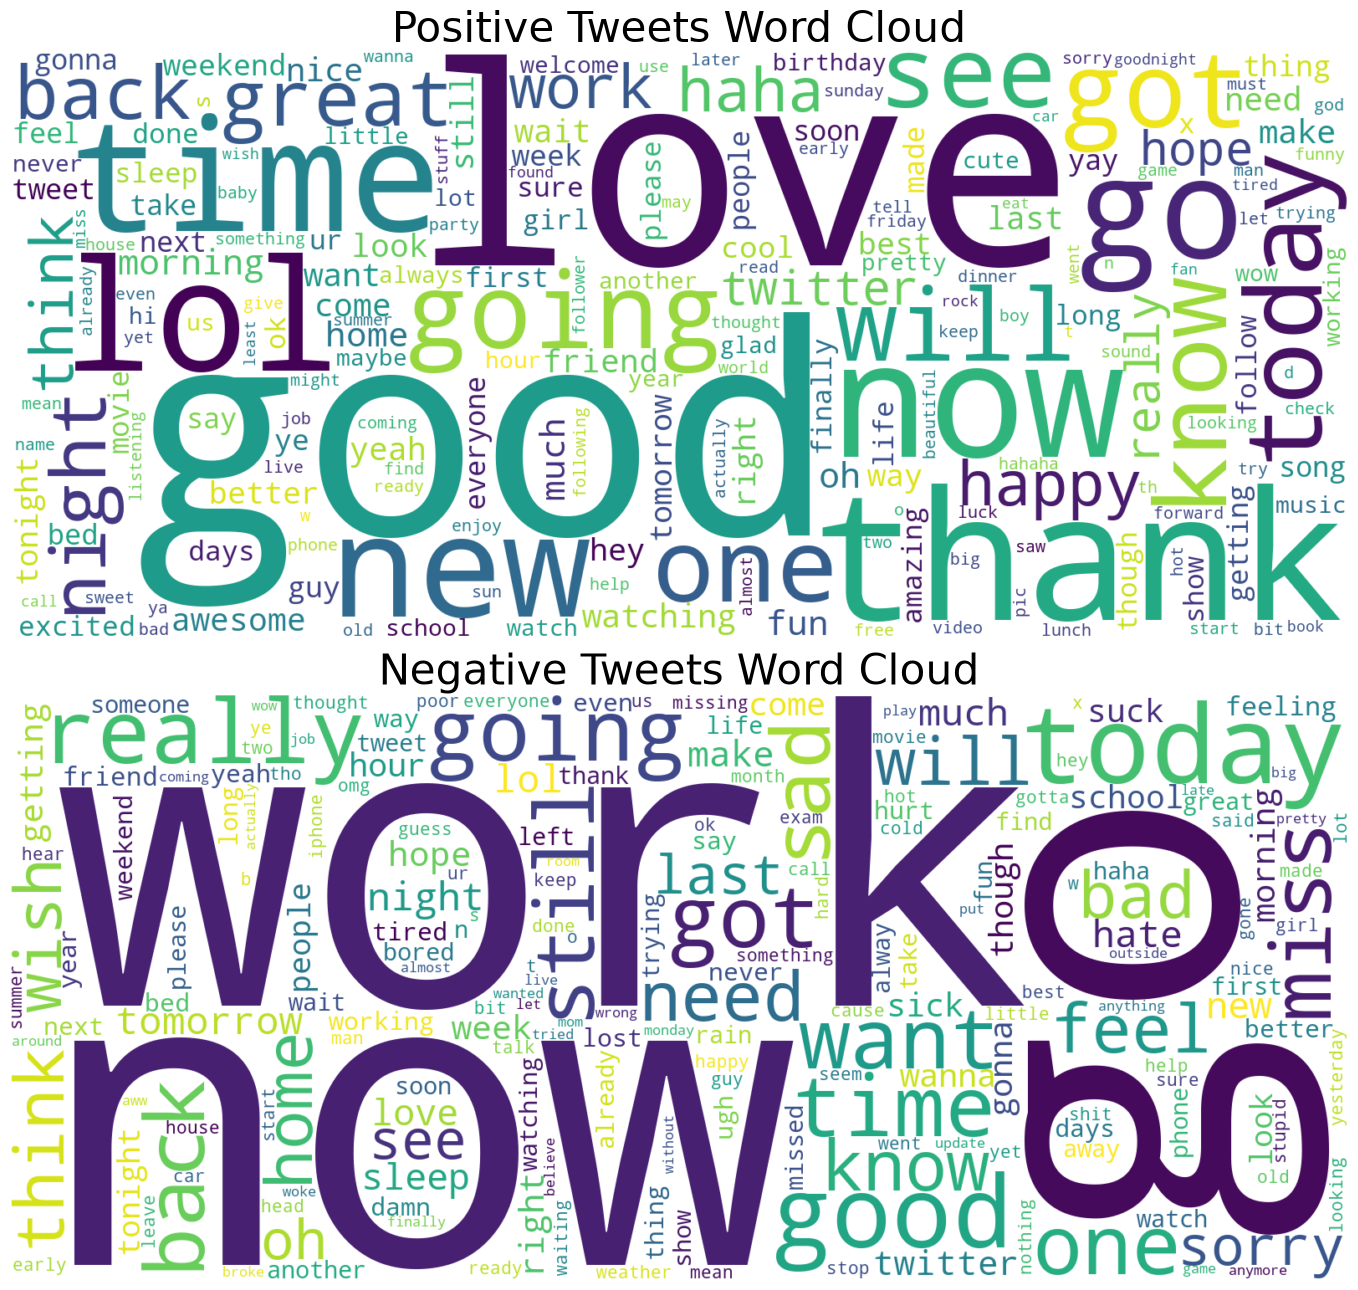

In [22]:
fig, axes = plt.subplots(2, 1, figsize=(14, 13))

axes[0].imshow(pos_wc, interpolation="bilinear")
axes[0].set_title("Positive Tweets Word Cloud", fontsize=30)
axes[0].axis("off")

axes[1].imshow(neg_wc, interpolation="bilinear")
axes[1].set_title("Negative Tweets Word Cloud", fontsize=30)
axes[1].axis("off")

plt.tight_layout()
plt.show()